In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [2]:
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
df.describe()

# categorical variables are removed from describe() output

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [4]:
# drop the unrequired columns; may be analyzed later to improve model accuracy
df = df.drop(columns=["MODELYEAR", "MAKE",	"MODEL",	"VEHICLECLASS", "TRANSMISSION",	"FUELTYPE"])
df.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244


In [5]:
# correlation matrix
df.corr()

# ENGINESIE and CYLINDERS are also highly correlated; only ENGINESIZE is kept since it has a higher correlation with y variable
# the four FUELCONSUMPTION columns are highly correlated to each other; hence only 1 can be retained that has the highest correlation with y variable

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [6]:
df = df[["ENGINESIZE", "FUELCONSUMPTION_COMB_MPG", "CO2EMISSIONS"]]
df.head()

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244


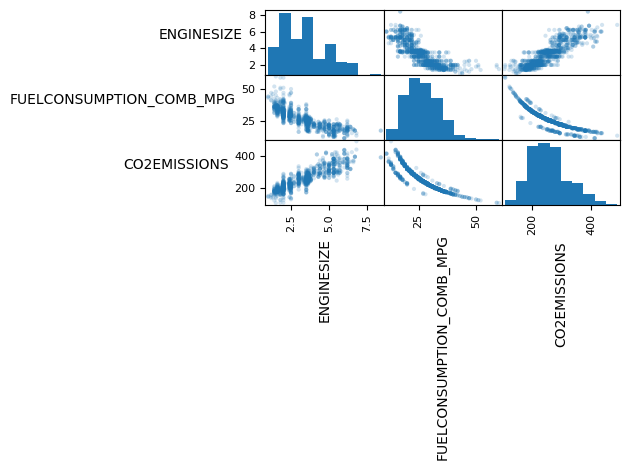

In [56]:
# scatter matrix
axes = pd.plotting.scatter_matrix(df, alpha=0.2)

# rotate X and Y axis labels for readability
for ax in axes.flatten():
  ax.xaxis.label.set_rotation(90)
  ax.yaxis.label.set_rotation(0)

  # set horizontal alignment of y axis labels
  ax.yaxis.label.set_ha("right")
plt.tight_layout()
#plt.figure(figsize=(15,8))
# adjust subplot layout parameters
plt.gcf().subplots_adjust(hspace=0, wspace=0)

# slight non-linear relationship between CO2EMISSIONS and FUELCONSUMPTION_COMB_MPG

In [38]:
# extract input features and labels
X = df[["ENGINESIZE", "FUELCONSUMPTION_COMB_MPG"]].to_numpy()
y = df["CO2EMISSIONS"].to_numpy()
print("X shape: ", X.shape)
print("y shape: ", y.shape)
print(X[0:10])
print(y[0:10])

X shape:  (1067, 2)
y shape:  (1067,)
[[ 2.  33. ]
 [ 2.4 29. ]
 [ 1.5 48. ]
 [ 3.5 25. ]
 [ 3.5 27. ]
 [ 3.5 28. ]
 [ 3.5 28. ]
 [ 3.7 25. ]
 [ 3.7 24. ]
 [ 2.4 31. ]]
[196 221 136 255 244 230 232 255 267 212]


In [46]:
# normalize the features, i.e. subtract the mean and divide by the standard deviation
std_scaler = StandardScaler()
X = std_scaler.fit_transform(X)
pd.DataFrame(X).describe().round(2)

# mean is now 0 and standard deviation is 1 for both the features

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


In [50]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (853, 2)
X_test (214, 2)
y_train (853,)
y_test (214,)


In [51]:
# linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [52]:
print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

# since there are two features, there will be best-fit plane instead of best-fit line

Intercept:  256.2907248808642
Coefficients:  [ 25.27339614 -37.4381472 ]


In [54]:
y_predict = model.predict(X_test)
print(y_predict[0:10])

[307.75418265 246.20424407 283.09521026 237.27517562 209.38699514
 252.32024098 308.17031919 295.25348681 313.11162372 308.17031919]


In [55]:
# evaluate the model
print("R2 score: ", r2_score(y_test, y_predict))
print("Mean absolute error: ", mean_absolute_error(y_test, y_predict))
print("Mean squared error: ", mean_squared_error(y_test, y_predict))
print("Root mean squared error: ", root_mean_squared_error(y_test, y_predict))

R2 score:  0.8872746641384827
Mean absolute error:  14.285849104574146
Mean squared error:  466.11311996611664
Root mean squared error:  21.589653076557685
